# 1. Импорты

In [77]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from scipy.stats import chi2_contingency

pd.set_option('display.width', 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
previous_loans = pd.read_csv(DATA_DIR / "previous_loans.csv")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

# 2. Функции

In [78]:
def leakage_check(df, col, target='target'):
     """
     сравнивает распределение значений признака и долю nan-значений между
     группами target=0 и target=1. Использую ее для проверки на утечку данных.
     Если распределение слишком чисто разделяет классы
     (квартили не пересекаются, доля пропусков резко отличается),
     это может означать, что признак содержит информацию, недоступную
     на момент подачи заявки, а не реальную связь с риском
     """
     missing_rate = df.groupby(target)[col].apply(lambda x: x.isna().mean())

     if pd.api.types.is_numeric_dtype(df[col]):
          info = df.groupby(target)[col].describe()
     else: 
          info = df.groupby(target)[col].value_counts(normalize=True)

     return info, missing_rate

In [79]:
from scipy.stats import chi2_contingency, ttest_ind

def chi2(column1, column2, data, verbose=True):
    """
    Функция считает хи-квадрат и p-value для двух категориальных признаков, 
    а также рассчитывает коэффицент Крамера (Cramer's V) 
    и ожидаемый уровень V при чистом шуме (H0)
    """
    contingency = pd.crosstab(data[column1], data[column2], dropna=False)
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    noise_floor_v = np.sqrt(dof / n)

    if verbose:
        print(f"p-value = {p_value:.4f}, Cramer's V = {cramers_v:.4f}")
        print(f"ожидаемый уровень V при чистом шуме (H0) = {noise_floor_v:.4f}")
        print(f"expected.min() = {expected.min():.2f}")

    return p_value, cramers_v  


def ttest(column1, column2, data, verbose=True):
    """
    Функция считает t-test и p-value для непрерывного и категориального признака (target), 
    а также рассчитывает n^2 (eta squared) и количество наблюдений в каждой группе
    """
    group1 = data[data[column2] == 0][column1]
    group2 = data[data[column2] == 1][column1]
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    n1, n2 = group1.notna().sum(), group2.notna().sum()
    df = n1 + n2 - 2
    eta_squared = t_stat**2 / (t_stat**2 + df)

    if verbose:
        print(f"p-value = {p_value:.5f}")
        print(f"η² (eta squared) = {eta_squared:.4f}")

    return p_value, eta_squared


In [80]:
def calc_woe_iv(df, feature, target, n_start_bins=10, min_bin_frac=0.05, p_merge_threshold=0.05, categorical_feature=None):
    """
    Считает woe (weight of evidence) и iv (information value) признака относительно таргета.

    Для числовых признаков сначала режет на n_start_bins бинов по квантилям,
    затем объединяет соседние бины, если разница в bad_rate между ними
    статистически незначима (chi2, p > p_merge_threshold) или бин слишком мал
    (< min_bin_frac от выборки). Так итоговые бины получаются крупнее и стабильнее.
    Для категориальных признаков бином считается сама категория.
    Пропуски идут отдельным бином 'Missing'.

    categorical_feature позволяет явно указать тип признака вместо автоопределения
    по dtype, это оказалось важно для бинарных числовых флагов (например has_bureau),
    которые по dtype выглядят как числовые, но по смыслу являются категориальными
    """
    x = df[feature]
    y = df[target]

    if categorical_feature is None: 
        categorical_feature = not pd.api.types.is_numeric_dtype(x)

    is_numeric = not categorical_feature

    if is_numeric:
        # стартовое разбиение на бины
        bins = pd.qcut(x, q=n_start_bins, duplicates='drop')

        # дообавляю категорию для пропусков, если они есть и заполняю ее
        bins = bins.cat.add_categories(['Missing']).fillna('Missing')

        # сортировка бингов в порядке возрастания
        order = sorted([c for c in bins.cat.categories if c != 'Missing'], key=lambda iv: iv.left)

        # приклеиваю missing в конец списка, так как у него нет числовой позиции
        if 'Missing' in bins.unique():
            order += ['Missing']
    else:
        # случай категориального признака, заменяю пропуски на missing
        bins = x.astype('object').fillna('Missing')
        order = list(pd.unique(bins))

    work = pd.DataFrame({'bin': bins, 'target': y})

    def bin_table(order):
        g = work.groupby('bin', observed=True)['target'].agg(n='size', bad='sum')
        g['good'] = g['n'] - g['bad']
        return g.reindex(order)

    n_total = len(work)
    min_n = n_total * min_bin_frac

    while len(order) > 2:
        table = bin_table(order)


        best_p, best_i = -1, None
        for i in range(len(order) - 1):
            ct = table.loc[[order[i], order[i+1]], ['good', 'bad']].values
            if ct.sum() == 0:
                continue
            _, p, _, _ = chi2_contingency(ct)
            if p > best_p:
                best_p, best_i = p, i

        smallest_i = table['n'].values.argmin()
        need_merge_small = table['n'].iloc[smallest_i] < min_n

        if best_p > p_merge_threshold or need_merge_small:
            i = best_i if best_p > p_merge_threshold else max(min(smallest_i, len(order) - 2), 0)
            merged = f"{order[i]} + {order[i+1]}" if not is_numeric else order[i]
            work['bin'] = work['bin'].replace({order[i]: merged, order[i+1]: merged})
            order = order[:i] + [merged] + order[i+2:]
        else:
            break

    g = bin_table(order)
    total_good, total_bad = g['good'].sum(), g['bad'].sum()
    g['bad_rate'] = g['bad'] / g['n']
    g['dist_good'] = (g['good'] / total_good).replace(0, 1e-6)
    g['dist_bad'] = (g['bad'] / total_bad).replace(0, 1e-6)
    g['woe'] = np.log(g['dist_good'] / g['dist_bad'])
    g['iv_bin'] = (g['dist_good'] - g['dist_bad']) * g['woe']

    return g[['n', 'bad', 'bad_rate', 'woe', 'iv_bin']], g['iv_bin'].sum()


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    v = np.sqrt((chi2 / n) / k) if k > 0 else np.nan
    return v, p

In [81]:
def plot_distribution(data, x, max_unique_for_bar=15):
    """
    Функция строит гистограмму распределения признака x
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    # гистограмма для нерпрерывных признаков
    if pd.api.types.is_numeric_dtype(data[x]) and data[x].nunique() > max_unique_for_bar:
        ax.hist(data[x].dropna(), bins=30, color='#4C72B0')
    # столбчатая диаграмма для категориальных признаков
    else:
        if pd.api.types.is_numeric_dtype(data[x]):
            vc = data[x].value_counts().sort_index()  
            vc.index = vc.index.astype(str)
            n_missing = data[x].isna().sum()
            if n_missing:
                vc['Missing'] = n_missing               
        else:
            vc = data[x].fillna('Missing').value_counts()
        vc.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Распределение {x}')
    plt.tight_layout()
    plt.show()


def visualization(woe_table, x, target):
    """
    Фукнкция строт два графика: количество наблюдений по бинам
    и долю target=1 по бинам. Бины берутся из таблицы woe_table
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = [str(i) for i in woe_table.index]

    axes[0].bar(labels, woe_table['n'], color="#3B5988")
    axes[0].set_title(f'Кол-во наблюдений по бинам {x}')
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)

    axes[1].bar(labels, woe_table['bad_rate'], color="#DD8452")
    for i, n in enumerate(woe_table['n']):
        axes[1].text(i, woe_table['bad_rate'].iloc[i] + 0.01, f'n={n}', ha='center', fontsize=8)
    axes[1].set_title(f'Доля {target}=1 по бинам {x}')
    axes[1].set_ylabel(f'доля {target}=1')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)

    plt.tight_layout()
    plt.show()

In [82]:
def feature_significance_table(features, target, data, categorical_features=None):
    """
    Функция строит таблицу с p-value, силой эффекта (Cramer's V/eta squared) и IV
    для списка признаков — для быстрой оценки значимости всех фичей разом.
    """
    categorical_features = set(categorical_features or [])
    results = []
    for col in features:
        kind = 'categorical' if col in categorical_features else 'continuous'

        if kind == 'continuous':
            p, effect = ttest(col, target, data, verbose=False)
            test_name = 'ttest'
        else:
            p, effect = chi2(col, target, data, verbose=False)
            test_name = 'chi2'

        woe_table, iv = calc_woe_iv(data, col, target, categorical_feature=(col in categorical_features))
        results.append({'feature': col, 'kind': kind, 'test': test_name, 'p_value': p, 'effect': effect, 'IV': iv})

    return pd.DataFrame(results).sort_values('IV', ascending=False).reset_index(drop=True).round(4)

In [83]:
def fit_woe(df, feature, target, is_categorical, n_bins=10, smoothing=0.5):
    """
    Считает woe-биннинг признака на df и возвращает готовые правила
    (границы бинов + woe каждого бина) для применения через transform_woe.
    """
    x = df[feature]
    y = df[target]

    if is_categorical:
        bin_of = x.astype('object').fillna('Missing')
        edges = None
    else:
        _, edges = pd.qcut(x, q=n_bins, duplicates='drop', retbins=True)
        edges[0], edges[-1] = -np.inf, np.inf
        bin_of = pd.cut(x, bins=edges).astype('object').fillna('Missing')

    table = pd.DataFrame({'bin': bin_of, 'target': y})
    agg = table.groupby('bin', observed=True)['target'].agg(n='size', bad='sum')
    agg['good'] = agg['n'] - agg['bad']

    total_good, total_bad = agg['good'].sum(), agg['bad'].sum()
    dist_good = (agg['good'] + smoothing) / (total_good + smoothing * len(agg))
    dist_bad = (agg['bad'] + smoothing) / (total_bad + smoothing * len(agg))
    woe = np.log(dist_good / dist_bad)

    return {'is_categorical': is_categorical, 'edges': edges,
            'woe_map': woe.to_dict(), 'default_woe': 0.0}


def transform_woe(df, feature, fitted):
    """
    Применяет уже готовые правила из fit_woe к df, заменяя значения признака на woe
    """
    x = df[feature]
    if fitted['is_categorical']:
        bin_of = x.astype('object').fillna('Missing')
    else:
        bin_of = pd.cut(x, bins=fitted['edges']).astype('object').fillna('Missing')
    return bin_of.map(fitted['woe_map']).fillna(fitted['default_woe'])

# 3. Предобработка данных

## 3.1. Работа с основной таблицей


In [84]:
# проверяю размеры таблиц 

print("train:", train.shape, train.shape)
print("test:", test.shape, test.shape)
print("buro:", bureau.shape)
print("transactions:", transactions.shape)
print("previous_loans:", previous_loans.shape)


train: (6488, 25) (6488, 25)
test: (2520, 24) (2520, 24)
buro: (24689, 8)
transactions: (353300, 6)
previous_loans: (12762, 7)


In [85]:
# удаляю дубли строк в train, в test их нет

print(f'дубликатов в train = {train.duplicated().sum()}')
print(f'дубликатов в test = {test.duplicated().sum()}')

train = train.drop_duplicates().reset_index(drop=True)

дубликатов в train = 8
дубликатов в test = 0


Feature engineering основной таблицы

In [86]:
train.columns

Index(['application_id', 'client_id', 'employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount',
       'internal_decision_code', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount',
       'marketing_segment', 'post_loan_collection_score', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents',
       'days_until_first_overdue', 'loan_term_months', 'siberia_northern_score', 'target'],
      dtype='str')

In [87]:
# утечка: признак фактически кодирует факт просрочки

leakage_check(train, 'days_until_first_overdue') 
train = train.drop('days_until_first_overdue', axis=1)
test = test.drop('days_until_first_overdue', axis=1)

In [88]:
# утечка: оценка коллекторов считается после выдачи займа, недоступна на момент заявки

leakage_check(train, 'post_loan_collection_score') 
train = train.drop('post_loan_collection_score', axis=1)
test = test.drop('post_loan_collection_score', axis=1)

In [89]:
# утечка: неизвестно, когда признак фиксируется

leakage_check(train, 'internal_decision_code')
train = train.drop('internal_decision_code', axis=1)
test = test.drop('internal_decision_code', axis=1)

# остальные колонки проверены на проверены аналогично, утечек не обнаружил

In [90]:
# удаляю hash_id, дублирует client_id

train.groupby('hash_id')['client_id'].nunique().value_counts()
train = train.drop('hash_id', axis=1)
test = test.drop('hash_id', axis=1)

# удаляю константу, не несет сигнала для модели
train['region_coefficient'].value_counts(dropna=False)
train = train.drop('region_coefficient', axis=1)

In [91]:
# проверка различия monthly_income и incoming_amount

both = train['monthly_income'].notna() & train['incoming_amount'].notna()
print('оба заполнены:', both.sum())
print('из них совпадают:', (train.loc[both, 'monthly_income'] == train.loc[both, 'incoming_amount']).mean())

# там, где оба значения не nan, они полностью совпадают
# объединение признаков
train['income'] = train['monthly_income'].fillna(train['incoming_amount'])
test['income'] = test['monthly_income'].fillna(test['incoming_amount'])

оба заполнены: 5637
из них совпадают: 1.0


In [92]:
# денежные показатели обычно ассиметричны, устраняю симметрию логарифмированием

print(f"ассиметрия income: {train['income'].skew()}")
print(f"ассиметрия loan_amount: {train['loan_amount'].skew()}")

train['log_income'] = np.log(train['income'] + 1)
test['log_income'] = np.log(test['income'] + 1)

train['log_loan_amount'] = np.log1p(train['loan_amount'])
test['log_loan_amount'] = np.log1p(test['loan_amount'])  

ассиметрия income: 1.809429878655907
ассиметрия loan_amount: 2.0829455188681103


In [93]:
# создание новых признаков

# платежеспособность
train['loan_by_income'] = train['loan_amount'] / train['income']
test['loan_by_income'] = test['loan_amount'] / test['income']

# доход на члена семьи
train['income_per_person'] = (train['income'] / (train['dependents'] + 1))
test['income_per_person'] = (test['income'] / (test['dependents'] + 1))

In [94]:
train['loan_by_income']

0       2.087560
1       4.361774
2       2.290501
3       2.459599
4       5.403006
          ...   
6475         NaN
6476    0.685884
6477    2.435990
6478    4.460174
6479    5.894727
Name: loan_by_income, Length: 6480, dtype: float64

## 3.2 Работа с дополнительными таблицами

Таблицы bureau, previous_loans, transactions нельзя просто смержить по client_id, потому что каждому client_id в этих таблицах может соответствовать несколько строк. Данные можно объединить, предварительно сгруппировав их по client_id и вычислив различные показатели (min, max, mean...)

In [95]:
transactions.head()

,client_id,application_id,transaction_date,transaction_category,amount,merchant_risk_level
0,1,100001,2025-10-22,transfer,-1538.95,5.0
1,1,100001,2025-07-10,cash_withdrawal,-1460.46,1.0
2,1,100001,2025-11-01,utilities,-988.50,2.0
3,1,100001,2025-10-10,salary,8578.27,3.0
4,1,100001,2025-12-24,entertainment,-2015.69,2.0


Feature engineering transactions

In [96]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# агрегация по числовым признакам
transactions_agg = transactions.groupby('client_id').agg(
    # счет, сумма, среднее, медиана, отклонение всех транзакций
    transactions_count = ('amount', 'count'),
    transactions_amount_sum = ('amount', 'sum'),
    transactions_amount_mean = ('amount', 'mean'),
    transactions_amount_median = ('amount', 'median'),
    transactions_amount_std = ('amount', 'std' ),

    # среднее риска транзакции
    transactions_risk_mean = ('merchant_risk_level', 'mean')

).reset_index()

# считаю долю каждой категории транзакций у каждого клиента 
transactions_category = pd.crosstab(transactions['client_id'], transactions['transaction_category'], normalize='index').reset_index()

# объединяю доли категорий с созданными числовыми признаками
transactions_agg = transactions_agg.merge(transactions_category, on='client_id', how='left')

# временной признак: сколько дней назад была последняя транзакция до подачи заявки

dates = pd.concat([
    train[['application_id', 'application_date']],
    test[['application_id', 'application_date']],
])
dates['application_date'] = pd.to_datetime(dates['application_date'])

transactions_with_date = transactions.merge(dates, on='application_id', how='inner')
transactions_with_date['days_before_application'] = (
    transactions_with_date['application_date'] - transactions_with_date['transaction_date']
).dt.days

recency = transactions_with_date.groupby('client_id')['days_before_application'].min().rename('days_since_last_transactions').reset_index()
transactions_agg = transactions_agg.merge(recency, on='client_id', how='left')

# доходные и расходные признаки

income = transactions.groupby('client_id')['amount'].apply(lambda x: x[x > 0].sum())
expenses = transactions.groupby('client_id')['amount'].apply(lambda x: abs(x[x < 0].sum()))

# отсутствие доходов или расходов может иметь значение для оценки 
no_income = (income == 0).rename('no_income_transactions').astype(int).reset_index()
# no_expenses нет

# денежный поток
cash_flow = (income / expenses).replace([np.inf, -np.inf], np.nan).rename('cash_flow').reset_index()


In [97]:
# мержу все новые признаки в transactions
transactions_agg = transactions_agg.merge(cash_flow, on='client_id', how='left')
transactions_agg = transactions_agg.merge(no_income, on='client_id', how='left')

# мержу transactions в train и test
train = train.merge(transactions_agg, on='client_id', how='left')
test = test.merge(transactions_agg, on='client_id', how='left')

Feature engineering bureau

In [98]:
bureau.head()

,client_id,bureau_account_id,account_type,opened_days_ago,credit_limit,current_balance,max_dpd_last_12m,bureau_status
0,1,B1_0,credit_card,2410.0,20474.70,5760.10,0.0,active
1,2,B2_1,NaN,2983.0,61748.02,47175.10,1.0,active
2,3,B3_2,auto,943.0,93069.06,40725.25,15.0,active
3,3,B3_3,mortgage,2355.0,173852.51,57974.36,7.0,closed
4,3,B3_4,credit_card,302.0,24037.79,7801.91,1.0,closed


In [99]:
bureau_agg = bureau.groupby('client_id').agg(
    # счет счетов
    bureau_account_id_count = ('bureau_account_id', 'count'),

    #сумма, среднее, максимум, минимум, отклонение кредитного лимита
    credit_limit_sum = ('credit_limit', 'sum'),
    credit_limit_mean = ('credit_limit', 'mean'),
    credit_limit_max = ('credit_limit', 'max'),
    credit_limit_min = ('credit_limit', 'min'),
    credit_limit_std = ('credit_limit', 'std'),

    # сумма, среднее, максимум, минимум баланса
    current_balance_sum = ('current_balance', 'sum'),
    current_balance_mean = ('current_balance', 'mean'),
    current_balance_max = ('current_balance', 'max'),
    current_balance_min = ('current_balance', 'min'),

    # сумма, среднее, максимум, минимум просрочки 
    max_dpd_last_12m_max = ('max_dpd_last_12m', 'max'), 
    max_dpd_last_12m_min = ('max_dpd_last_12m', 'min'), 
    max_dpd_last_12m_mean = ('max_dpd_last_12m', 'mean'),
    max_dpd_last_12m_sum = ('max_dpd_last_12m', 'sum')
    
).reset_index()

# доля активных кредитов
bureau_active_status = bureau.groupby('client_id')['bureau_status'].apply(
    lambda x: (x == 'active').mean()
).rename('bureau_active_status').reset_index()

# доля кредитов по типам
bureau_account_type = pd.crosstab(bureau['client_id'], bureau['account_type'], normalize='index').reset_index()

In [100]:
print(f"кол-во client_id в bureau: {bureau['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - bureau['client_id'].nunique()} клиентов нет информации о внешней кредитной истории")

# дабавляю бинарный флаг: имеет ли клиент внешние долги
train['has_bureau'] = train['client_id'].isin(bureau['client_id']).astype(int)
test['has_bureau'] = test['client_id'].isin(bureau['client_id']).astype(int)

кол-во client_id в bureau: 8542
кол-во client_id в train и test: 9000
у 458 клиентов нет информации о внешней кредитной истории


In [101]:
# merge новых признаков с агрегированным bureau
bureau_agg = bureau_agg.merge(bureau_active_status, on='client_id', how='left')
bureau_agg = bureau_agg.merge(bureau_account_type, on='client_id', how='left')

# merge агрегированного bureau с train и test
train = train.merge(bureau_agg, on='client_id', how='left')
test = test.merge(bureau_agg, on='client_id', how='left')

Feature engineering previous_loans

In [102]:
loans_agg = previous_loans.groupby('client_id').agg(
    # количество прошлых займов
    previous_loan_count = ('previous_loan_id', 'count'),

    # сумма, среднее, минимум, максимум прошлых займов
    previous_amount_sum = ('previous_amount', 'sum'),
    previous_amount_mean = ('previous_amount', 'mean'),
    previous_amount_min = ('previous_amount', 'min'),
    previous_amount_max = ('previous_amount', 'max'),

    # 
    previous_term_months_mean = ('previous_term_months', 'mean'),
    previous_term_months_max = ('previous_term_months', 'max'),

    # 
    closed_days_ago_min = ('closed_days_ago', 'min'),

    # сумма, среднее просрочек
    was_overdue_sum = ('was_overdue', 'sum'),
    was_overdue_mean = ('was_overdue', 'mean'),

    # сумма, максимум дней просрочки
    max_overdue_days_max = ('max_overdue_days', 'max'),
    max_overdue_days_sum = ('max_overdue_days', 'sum')
    
).reset_index()

last_loan = (
    previous_loans
    .sort_values(['client_id', 'closed_days_ago'])
    .groupby('client_id', as_index=False)
    .first()[['client_id', 'was_overdue', 'max_overdue_days']]
    .rename(columns={
        'was_overdue': 'last_loan_was_overdue',
        'max_overdue_days': 'last_loan_max_overdue_days',
    })
)

print(f"кол-во client_id в previous_loans: {previous_loans['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - previous_loans['client_id'].nunique()} клиентов нет информации о прошлых займах")

# бинарный флаг: есть ли прошлые займы
train['has_previous_loans'] = train['client_id'].isin(previous_loans['client_id']).astype(int)
test['has_previous_loans'] = test['client_id'].isin(previous_loans['client_id']).astype(int)

кол-во client_id в previous_loans: 6885
кол-во client_id в train и test: 9000
у 2115 клиентов нет информации о прошлых займах


In [103]:
# merge новых признаков с агрегированной таблицей прошлых займов
loans_agg = loans_agg.merge(last_loan, on='client_id', how='left')

# merge с train и test
train = train.merge(loans_agg, on='client_id', how='left')
test = test.merge(loans_agg, on='client_id', how='left')

# 4. EDA

In [104]:
train.head()

,application_id,client_id,employment_type,region_coefficient_extended,age,incoming_amount,monthly_income,application_date,education,requested_product,...,previous_amount_max,previous_term_months_mean,previous_term_months_max,closed_days_ago_min,was_overdue_sum,was_overdue_mean,max_overdue_days_max,max_overdue_days_sum,last_loan_was_overdue,last_loan_max_overdue_days
0,107941,7941,employee,1.0,37.0,30401.28,30401.28,2025-08-11,bachelor,refinance,...,20623.70,36.0,36.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0
1,101163,1163,employee,0.0,60.0,26024.64,26024.64,2025-12-29,school,card,...,20284.16,24.0,24.0,1235.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100583,583,contractor,0.0,37.0,21389.83,21389.83,2025-11-09,college,cash,...,51317.01,6.0,6.0,873.0,1.0,0.5,7.0,7.0,0.0,7.0
3,104082,4082,NaN,0.0,NaN,31617.26,NaN,2025-02-23,college,card,...,141115.00,24.0,24.0,769.0,0.0,0.0,NaN,0.0,0.0,NaN
4,108413,8413,employee,0.0,60.0,18000.00,18000.00,2025-12-07,bachelor,card,...,37376.14,24.0,24.0,1059.0,0.0,0.0,0.0,0.0,0.0,0.0


<function matplotlib.pyplot.show(close=None, block=None)>

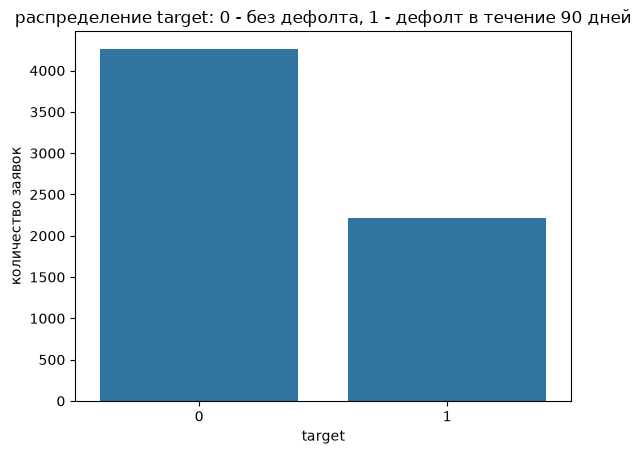

In [105]:
sns.countplot(data=train, x='target')

plt.title("распределение target: 0 - без дефолта, 1 - дефолт в течение 90 дней")
plt.xlabel('target')
plt.ylabel('количество заявок')

plt.show

In [106]:
# распределение классов в train
print(train['target'].value_counts(normalize=True))

target
0    0.657716
1    0.342284
Name: proportion, dtype: float64


Дисбаланс классов влияет на стратегию CV и обучение модели. Для равномерного распределения классов по фолдам я буду использовать далее StrarifieldKFold

## 4.1 Оценка значимости признаков

Для оценки значимости признаков использу следующий пайплайн. Для каждого признака исследуются статистическая значимость, сила эффекта и информационная ценность (IV).

1. P-value. Ориентир: `p < 0.05` - связь с таргетом статистически значима, то есть не объясняется случайностью.

У нас большая выборка, поэтому p-value может показывать значимость даже при незначительном эффекте, поэтому дополнительно измеряется сила эффекта:

- для категориальных признаков через коэффициент Крамера (V)
- для непрерывных признаков — через n^2 (eta squared)

На высококардинальных категориальных признаках V может быть завышен просто за счет размера таблицы сопряженности. В этих случаях V нужно сравнивать не с фиксированной шкалой Коэна, а с ожидаемым уровнем V при чистом шуме (H0).

Пороги по Коэну: 

V < 0.1        — слабая связь
0.1 < V < 0.3  — умеренная
0.3 ≤ V < 0.5  — сильная      
V ≥ 0.5        — очень сильная 

n^2 < 0.01        — слабая связь
0.01 < n^2 < 0.06 — умеренная
0.06 < n^2 < 0.14 — умеренная-сильная 
n^2 > 0.14        — сильная

V/n^2 измеряют связь одним усредненным числом по всей выборке и могут недооценивать признак, если сигнал сосредоточен в отдельных сегментах. IV считается по каждому бину отдельно и суммируется, поэтому решение об исключении признака я принимаю по порогу IV, а p-value/V/n^2 использую как проверку, что этот IV не шум

IV < 0.02        — признак бесполезен
0.02 < IV < 0.1  — слабая связь
0.1 < IV < 0.3   — умеренная связь
0.3 < IV < 0.5   — сильная связь

In [107]:
train.columns

Index(['application_id', 'client_id', 'employment_type', 'region_coefficient_extended', 'age', 'incoming_amount', 'monthly_income',
       'application_date', 'education', 'requested_product', 'channel', 'loan_amount', 'marketing_segment', 'region', 'interest_rate',
       'months_at_job', 'dependents', 'loan_term_months', 'siberia_northern_score', 'target', 'income', 'log_income', 'log_loan_amount',
       'loan_by_income', 'income_per_person', 'transactions_count', 'transactions_amount_sum', 'transactions_amount_mean',
       'transactions_amount_median', 'transactions_amount_std', 'transactions_risk_mean', 'cash_withdrawal', 'entertainment', 'gambling',
       'groceries', 'loan_payment', 'salary', 'transfer', 'utilities', 'days_since_last_transactions', 'cash_flow', 'no_income_transactions',
       'has_bureau', 'bureau_account_id_count', 'credit_limit_sum', 'credit_limit_mean', 'credit_limit_max', 'credit_limit_min', 'credit_limit_std',
       'current_balance_sum', 'current_balan

In [108]:
# вручную задаю список категориальных признаков
categorical_features = [
    'employment_type',
    'region_coefficient_extended',
    'education',
    'requested_product',
    'channel',
    'marketing_segment',
    'region',
    'dependents',                   

    'no_income_transactions',        
    'has_bureau',                   
    'has_previous_loans',          
    'last_loan_was_overdue',   
]

In [109]:
# исключаю из оценки технические признаки
exclude = ['application_id', 'client_id', 'application_date', 'target']

features = [c for c in train.columns if c not in exclude]

# строю таблицу значимости признаков
table = feature_significance_table(features, 'target', train, categorical_features=categorical_features)

In [110]:
# топ 20 самых сильных признаков
table[:20]

,feature,kind,test,p_value,effect,IV
0,max_dpd_last_12m_max,continuous,ttest,0.0,0.1187,0.5756
1,max_dpd_last_12m_sum,continuous,ttest,0.0,0.0996,0.5087
2,max_dpd_last_12m_mean,continuous,ttest,0.0,0.0818,0.4750
3,months_at_job,continuous,ttest,0.0,0.0608,0.3513
4,loan_by_income,continuous,ttest,0.0,0.0641,0.2550
5,employment_type,categorical,chi2,0.0,0.2296,0.2251
6,log_income,continuous,ttest,0.0,0.0390,0.1937
7,income,continuous,ttest,0.0,0.0276,0.1937
8,monthly_income,continuous,ttest,0.0,0.0267,0.1827
9,incoming_amount,continuous,ttest,0.0,0.0275,0.1788


## 4.2 Выборочный подробный анализ признаков

Вручную разбираю первые признаки по одному. Пайплайн:

1. Гипотеза - что ожидаю увидеть, до просмотра данных
2. Гистограмма распределения — форма, выбросы, доля пропусков
3. WoE-таблица — бины, bad_rate, IV
4. Графики n и bad_rate по бинам — проверка монотонности
5. Вывод

max_dpd_last_12m_max

гипотеза: чем больше самая тяжелая просрочка у клиента за последний год, тем выше риск выйти в новую серьезную просрочку

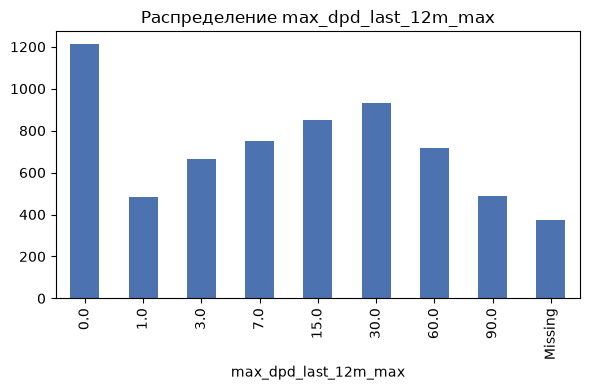

In [111]:
plot_distribution(train, 'max_dpd_last_12m_max')

In [112]:
woe_table, iv = calc_woe_iv(train, 'max_dpd_last_12m_max', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-0.001, 1.0]",3116,759,0.243582,0.480010,0.101199
"(7.0, 15.0]",853,256,0.300117,0.193607,0.004774
"(15.0, 30.0]",931,354,0.380236,-0.164587,0.003986
"(30.0, 60.0]",717,419,0.584379,-0.993910,0.118264
"(60.0, 90.0]",489,381,0.779141,-1.913801,0.280250
Missing,374,49,0.131016,1.238872,0.067101


In [113]:
print(f"iv: {iv:.4f}")

iv: 0.5756


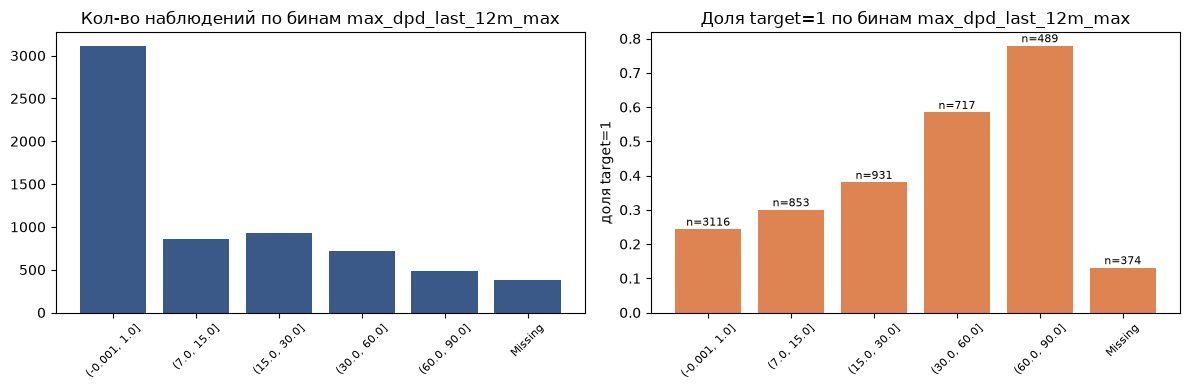

In [114]:
visualization(woe_table, 'max_dpd_last_12m_max', 'target')

Монотонный признак, оценка надежна (все бины > 5% выборки). IV = 0.57, признак легитимно сильный, данные не могут быть утечкой, так как информация получена из кредитной истории клиента. Бин пропущенных значений (Missing) дает самый низкий bad_rate (13%). Можно сделать вывод, что отсутствие кредитной истории уменьшает риск выйти в серьезную просрочку. Признак оставляю как один из ключевых. Гипотеза подтверждена

max_dpd_last_12m_sum и max_dpd_last_12m_mean

гипотеза: чем больше суммарная или средняя просрочка у клиента за последний год, тем выше риск выйти в новую серьезную просрочку

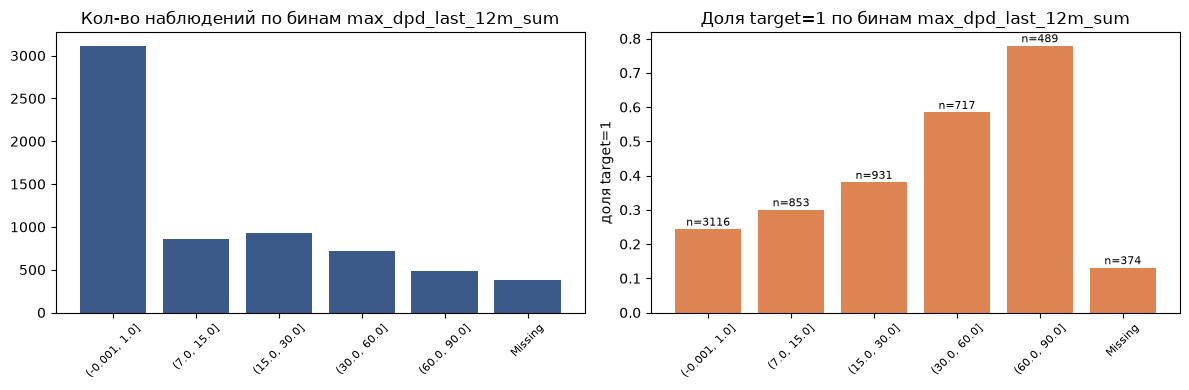

In [115]:
visualization(woe_table, 'max_dpd_last_12m_sum', 'target')

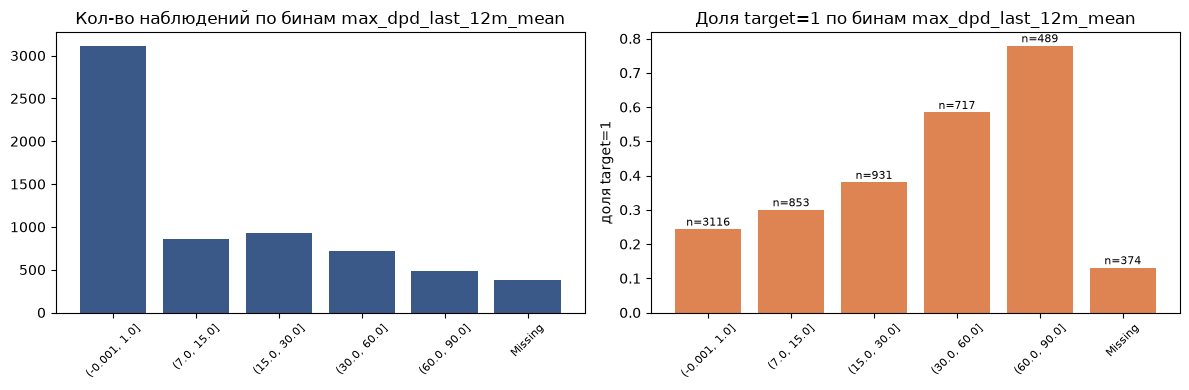

In [116]:
visualization(woe_table, 'max_dpd_last_12m_mean', 'target')

Графики среднего и суммы просрочек по аналогии монотонны

months_at_job 

гипотеза: меньше рабочий стаж -> меньше карьерный рост -> меньше заработная плата -> выше риск просрочки

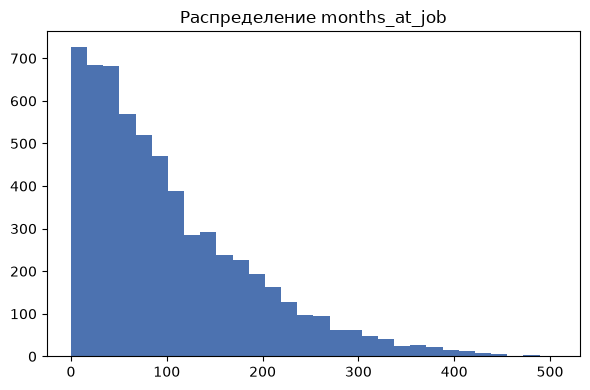

In [117]:
plot_distribution(train, 'months_at_job')

In [118]:
woe_table, iv = calc_woe_iv(train, 'months_at_job', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-0.001, 13.0]",1249,662,0.530024,-0.773373,0.124311
"(29.0, 43.0]",1219,550,0.451189,-0.457267,0.041612
"(61.0, 79.5]",1211,391,0.322874,0.087464,0.001409
"(102.0, 131.0]",1196,267,0.223244,0.593727,0.057944
"(170.4, 225.7]",1219,213,0.174733,0.899313,0.125910
Missing,386,135,0.349741,-0.032954,0.000065


In [119]:
print(f"IV = {iv:.4f}")

IV = 0.3513


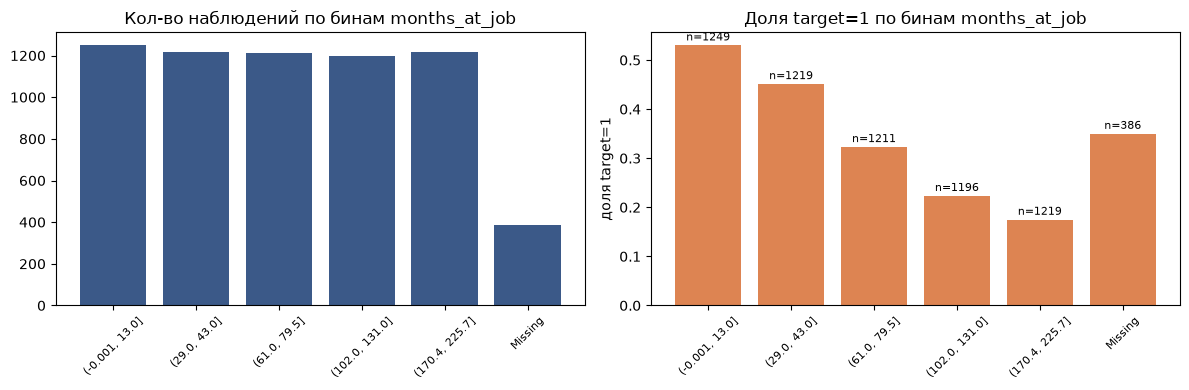

In [120]:
visualization(woe_table, 'months_at_job', 'target')

Признак монотонный, шанс просрочки уменьшается с ~ 53% в первом бине до ~ 17% в последнем числовом. Все бины > 5% выборки, оценка надежна. Бин с пропущенными значениями не несет сигнала, люди без стажа ведут себя в среднем одинаково. Оставляю признак как один из ключевых

loan_by_income

гипотеза - чем больше отношение долга к доходу (долг превышает доход), тем выше риск выйти в серьезную просрочку

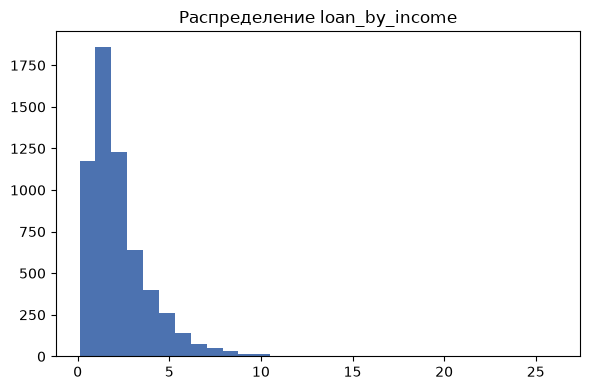

In [121]:
plot_distribution(train, 'loan_by_income')

In [122]:
woe_table, iv = calc_woe_iv(train, 'loan_by_income', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.10099999999999999, 0.707]",1770,402,0.227119,0.571520,0.079860
"(1.226, 1.491]",1769,520,0.293951,0.223137,0.013078
"(2.14, 2.585]",1180,428,0.362712,-0.089520,0.001479
"(3.254, 4.463]",590,289,0.489831,-0.612449,0.036547
"(4.463, 26.115]",590,362,0.613559,-1.115431,0.122379
Missing,581,217,0.373494,-0.135876,0.001689


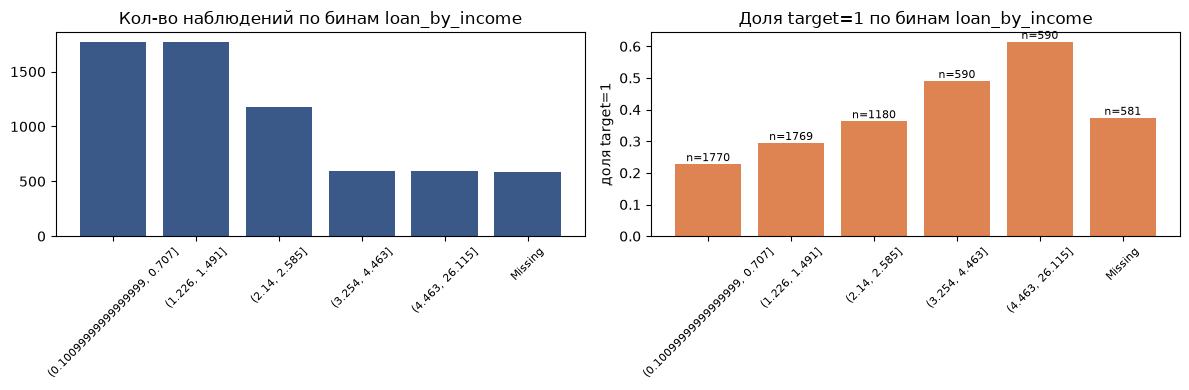

In [123]:
visualization(woe_table, 'loan_by_income', 'target')

Признак монотонный, от ~22 % до 61 % просрочки в последнем числовом бине. Бин с пропущенными значениями не несет сигнала. Оценка надежна, все бины больше 5 % выборки. Оставляю признак. Гипотеза подтверждена

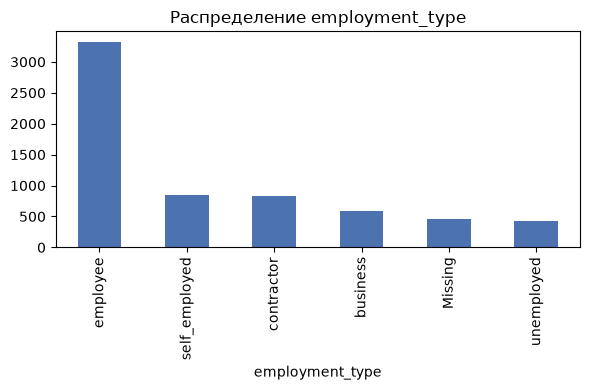

In [124]:
plot_distribution(train, 'employment_type')

In [125]:
woe_table, iv = calc_woe_iv(train, 'employment_type', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
employee,3327,981,0.294860,0.218762,0.023660
contractor,823,362,0.439854,-0.411379,0.022644
Missing + self_employed,1311,418,0.318841,0.105973,0.002233
unemployed,429,303,0.706294,-1.530584,0.163843
business,590,154,0.261017,0.387557,0.012738


In [126]:
print(f"IV = {iv:.4f}")

IV = 0.2251


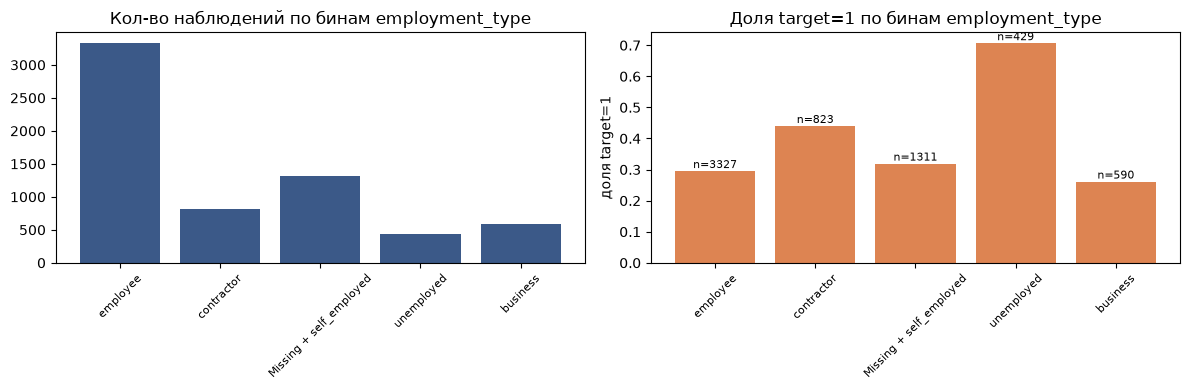

In [127]:
visualization(woe_table, 'employment_type', 'target')

Значительный выброс в unemployed - 70 % просрочки против 26-43 % в других категориях. Вклад категории в общую IV 0.164 из 0.225, то есть около 73% предсказательной силы. Оценка надежна, минимальное кол-во наблюдений в unemployed = 429, выше 5%. Самый низкий риск просрочки ожидаемо у employee/buisness. 

Функция смержила категорию с пропущенными значениями с self_employed, потому что их bad_rate статистически неразличим. Гипотеза: люди, которые не указали тип занятости чаще всего являются самозанятыми

log_income, income (monthly_income | incoming_amount) - имеют одинаковую IV

гипотеза: выше доход -> ниже риск просрочки

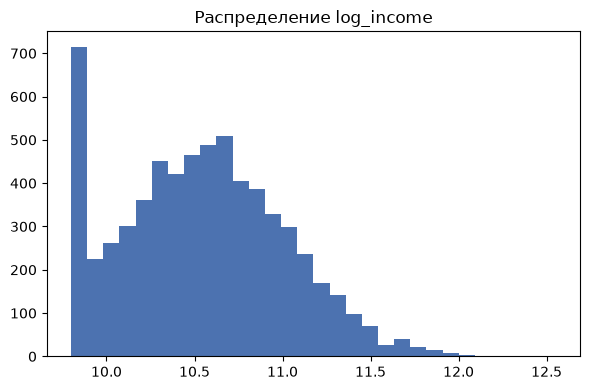

In [128]:
plot_distribution(train, 'log_income')

In [129]:
woe_table, iv = calc_woe_iv(train, 'log_income', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(9.797, 9.859]",646,367,0.568111,-0.927283,0.092730
"(9.859, 10.102]",645,299,0.463566,-0.507137,0.027195
"(10.102, 10.272]",645,255,0.395349,-0.228249,0.005355
"(10.272, 10.407]",2580,818,0.317054,0.114210,0.005096
"(10.789, 10.944]",1964,479,0.243890,0.478337,0.063364


In [130]:
print(f"IV = {iv:.4f}")

IV = 0.1937


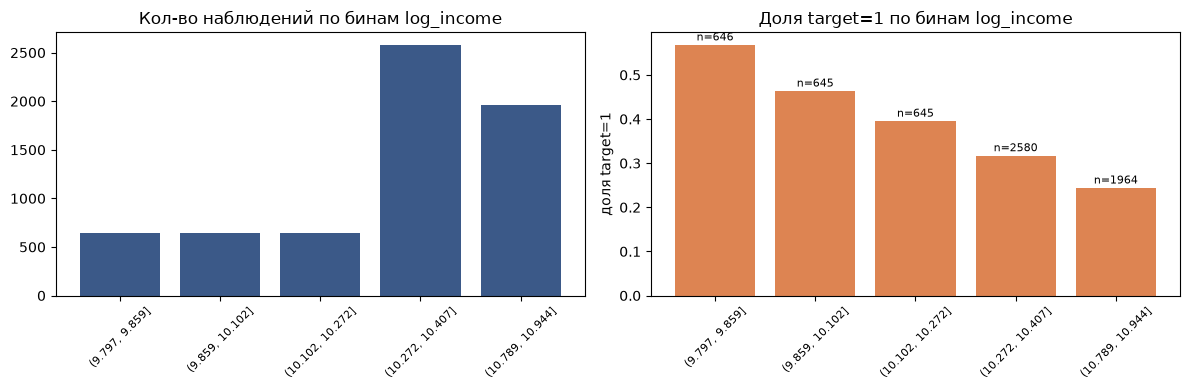

In [131]:
visualization(woe_table, 'log_income', 'target')

Монотонный признак, от ~ 56% просрочки у людей с самым низким доходом до ~ 24% у людей с высоким доходом. Признак надежный, количества наблюдений достаточно (выше 5% выборки в каждом бине). Гипотеза подтверждена

transactions_amount_median

типичный размер разового расхода/дохода клиента

крупная отрицательная медианная транзакция может означать либо более состоятельного клиента (риск просрочки ниже), либо отсутствие финансовой дисциплины (риск просрочки выше) 

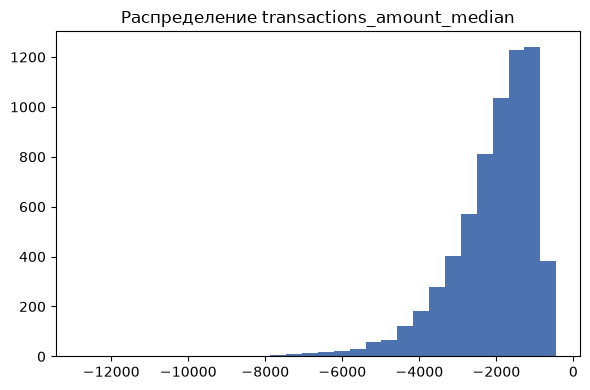

In [132]:
plot_distribution(train, 'transactions_amount_median')

In [133]:
woe_table, iv = calc_woe_iv(train, 'transactions_amount_median', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-12821.491, -3561.715]",1296,306,0.236111,0.520987,0.049141
"(-2849.834, -2415.742]",2592,784,0.302469,0.182435,0.012906
"(-1597.678, -1380.129]",648,229,0.353395,-0.048984,0.000242
"(-1380.129, -1156.88]",1296,545,0.420525,-0.332513,0.023112
"(-953.753, -445.84]",648,354,0.546296,-0.838850,0.076018


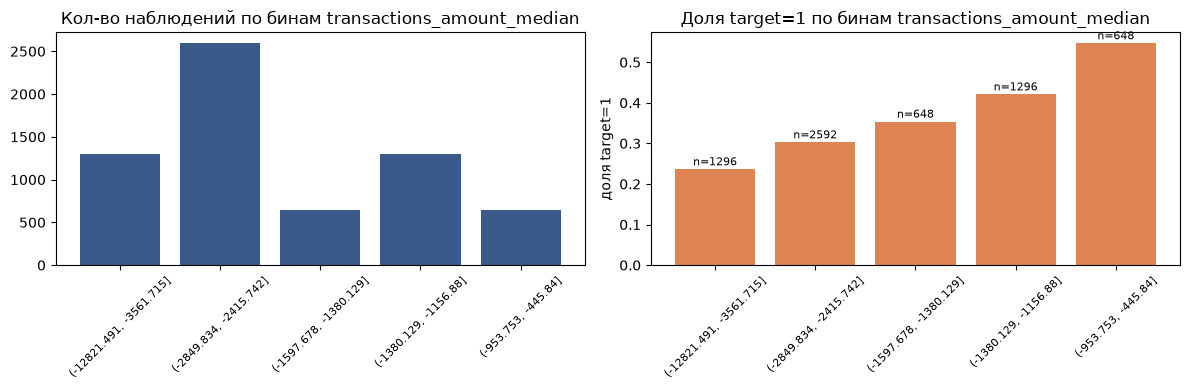

In [134]:
visualization(woe_table, 'transactions_amount_median', 'target')

Признак монотонный: чем мельче типичная разовая трата клиента, тем выше bad_rate (23.6% -> 54.4%). Подтверждает гипотезу, что крупные
типичные расходы ассоциируются с финансовой стабильностью, а не с жизнью не по средствам. Пропусков нет. Признак оставляю.


Интересно, что transactions_amount_sum, transactions_amount_mean, transactions_count показали меньшую статистическую значимость. Гипотеза: медиана и среднее отклонение как более устойчивые метрики поведения могут нести сигнал, который среднее/сумма размывают выбросами

age 

молодые клиенты, вероятно, имеют меньше опыта работы, находятся на более низких должностях чем старшие коллеги, следовательно, имеют в среднем меньше финансовой стабильности и выше риск выйти в серьезную просрочку

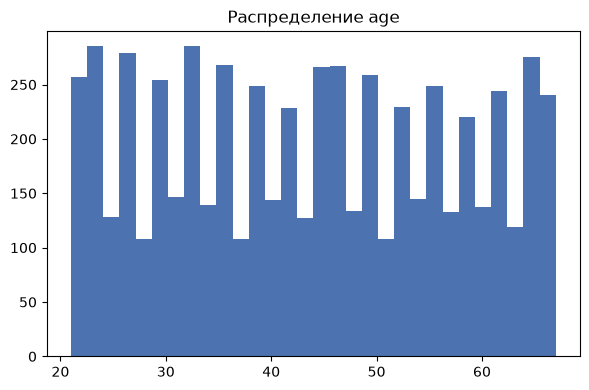

In [135]:
plot_distribution(train, 'age')

In [136]:
woe_table, iv = calc_woe_iv(train, 'age', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(20.999, 25.0]",670,336,0.501493,-0.659103,0.048194
"(25.0, 30.0]",1212,517,0.426568,-0.357264,0.025017
"(34.0, 39.0]",1263,439,0.347585,-0.023462,0.000108
"(44.0, 48.0]",2371,668,0.281738,0.282726,0.027822
"(63.0, 67.0]",515,102,0.198058,0.745342,0.037949
Missing,449,156,0.347439,-0.022816,0.000036


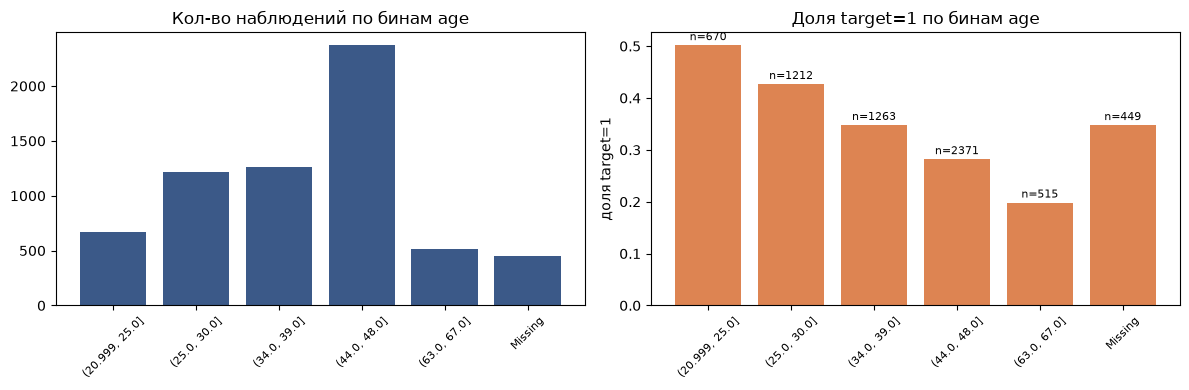

In [137]:
visualization(woe_table, 'age', 'target')

Монотонный признак, чем меньше возраст, тем выше риск просрочки (20-25 лет - 50 % просрочки). Бин с пропусками не несет интересного сигнала. Количество наблюдений достаточно, чтобы считать оценку надежной (каждый бин > 5% от выборки)

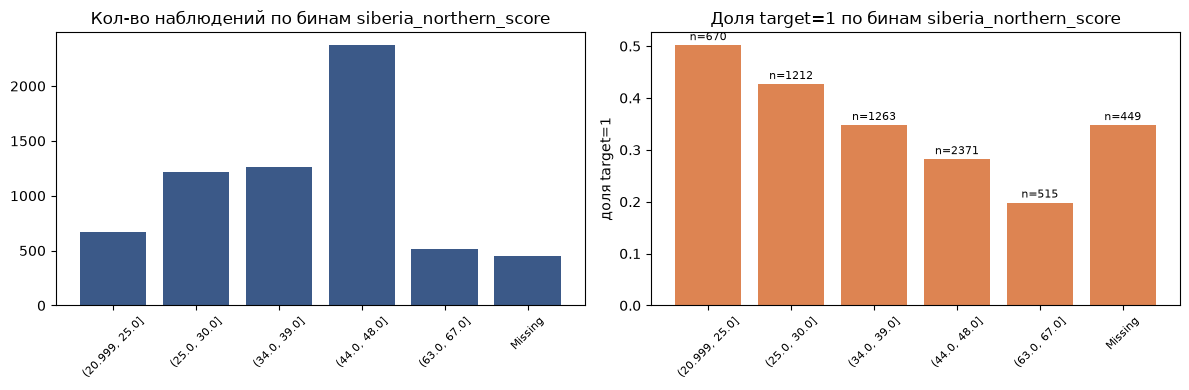

In [138]:
visualization(woe_table, 'siberia_northern_score', 'target')

In [139]:
woe_table, iv = calc_woe_iv(train, 'siberia_northern_score', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-0.000891, 0.1]",4235,1475,0.348288,-0.026560,0.000463
"(0.707, 0.804]",2245,743,0.330958,0.050724,0.000884


In [140]:
print(f"IV = {iv:.4f}")

IV = 0.0013


In [141]:
ttest('siberia_northern_score', 'target', train)

p-value = 0.74113
η² (eta squared) = 0.0000


(np.float64(0.7411250272794542), np.float64(1.804701293595896e-05))

Выводы по EDA

In [142]:
table[-30:] # топ 30 бесполезных признаков

,feature,kind,test,p_value,effect,IV
44,transactions_risk_mean,continuous,ttest,0.0617,0.0005,0.0119
45,previous_amount_sum,continuous,ttest,0.0072,0.0015,0.0105
46,gambling,continuous,ttest,0.0013,0.0016,0.0105
47,region,categorical,chi2,0.0096,0.0535,0.0091
48,previous_loan_count,continuous,ttest,0.0059,0.0015,0.0084
49,previous_term_months_mean,continuous,ttest,0.4110,0.0001,0.0081
50,previous_amount_min,continuous,ttest,0.9588,0.0000,0.0079
51,previous_amount_max,continuous,ttest,0.0965,0.0006,0.0078
52,groceries,continuous,ttest,0.6269,0.0000,0.0075
53,previous_amount_mean,continuous,ttest,0.3108,0.0002,0.0073


In [143]:
# удаляю все признаки с IV < 0.02
features_to_drop = set([feature for feature in table[table['IV'] < 0.02]['feature'].tolist()])

features_to_drop.update([
    # признаки объединенные в income
    'incoming_amount', 'monthly_income', 
    # бесполезный признак для модели
    'application_date',
    # логарифмированные признаки
    'income', 'loan_amount'
])

In [144]:
train = train.drop(columns=features_to_drop, errors='ignore')
test = test.drop(columns=features_to_drop, errors='ignore')

In [145]:
train.isna().sum()

application_id                   0
client_id                        0
employment_type                465
age                            449
requested_product              382
interest_rate                  375
months_at_job                  386
loan_term_months               525
target                           0
log_income                      28
log_loan_amount                556
loan_by_income                 581
income_per_person              493
transactions_amount_sum          0
transactions_amount_mean         0
transactions_amount_median       0
transactions_amount_std          0
has_bureau                       0
bureau_account_id_count        337
credit_limit_sum               337
credit_limit_mean              377
credit_limit_max               377
credit_limit_min               377
credit_limit_std              1546
current_balance_sum            337
current_balance_mean           358
current_balance_max            358
current_balance_min            358
max_dpd_last_12m_max

# 5. Обучение и валидация

Пайплайн:

1. Для логистической регрессии делаю отдельный набор признаков через WoE-трансформацию — числовые признаки бью на бины по квантилям, категориальные кодирую по самим категориям, пропуски идут отдельным бином. WoE считаю только на train-части фолда, чтобы не было утечки таргета в валидацию

2. Для случайного леса и бустинга использую единый пайплайн. Сырые признаки: числовые NaN заполняю медианой, категориальные модой и OrdinalEncoder

3. В валидации использую StratifiedKFold, 5 фолдов, чтобы доля дефолтов была одинаковой в каждом сплите

4. Внутри одного цикла по фолдам обучаю все три модели, смотрю AUC каждой отдельно и AUC бленда, чтобы понимать, реально ли блендинг что-то дает сверх лучшей одиночной модели

5. Гиперпараметры каждой модели подбираю отдельно перебором через GridSearch.

Комментарий: изначально я протестировал блендинг трех моделей, но оказалось, что случайный лес уступал по roc-auc всем моделям и немного тянул бленд вниз (0.8301 с ним и 0.8316 без него), поэтому я принял решение удалить RandomForestClassifier из финального ноутбука

In [ ]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# StratifiedKFold для сохранения баланса классов
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [147]:
# все признаки для моделей, кроме технических и target
features_raw = [c for c in train.columns if c not in ['target', 'application_id', 'client_id']]

# обновляю признаки после удаления бесполезных
categorical_features = [c for c in categorical_features if c in features_raw]
numeric_features = [c for c in features_raw if c not in categorical_features]

print(f"всего признаков: {len(features_raw)}, категориальных: {len(categorical_features)}, числовых: {len(numeric_features)}")


всего признаков: 40, категориальных: 4, числовых: 36


In [148]:
# общий пайплайн для деревьев, чтобы корректно обработались nan и строковые значения 
def make_tree_pipeline(estimator):
    preprocessor = ColumnTransformer([
        # для числовых признаков
        ('num', SimpleImputer(strategy='median'), numeric_features),
        # для категориальных
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), categorical_features),
    ])
    return Pipeline([('preprocessor', preprocessor), ('model', estimator)])


In [149]:
# поиск оптимальных параметров для логистической регресси через grid search
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
}

search_logreg = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=1),
    param_grid=param_grid_logreg,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
)

# woe-трансформация признаков для корректной работы модели
X_train_woe = pd.DataFrame(index=train.index)
for feature in features_raw:
    is_cat = feature in categorical_features
    fitted = fit_woe(train, feature, 'target', is_categorical=is_cat)
    X_train_woe[feature] = transform_woe(train, feature, fitted)

search_logreg.fit(X_train_woe, train['target'])

print('Лучшие параметры log_reg:', search_logreg.best_params_)
print('Лучший CV roc_auc:', search_logreg.best_score_)


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To 

Лучшие параметры log_reg: {'C': 0.1, 'penalty': 'l2'}
Лучший CV roc_auc: 0.8350973116694289


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [150]:
# сырые признаки для деревьев (без woe-трансформации)
X_train_raw = train[features_raw]

In [152]:
# аналогично для бустинга
param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__num_leaves': [15, 31, 63],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

search_lgbm = GridSearchCV(
    estimator=make_tree_pipeline(LGBMClassifier(random_state=1)),
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
)
search_lgbm.fit(X_train_raw, train['target'])

print('Лучшие параметры lgmm:', search_lgbm.best_params_)
print('Лучший CV roc_auc:', search_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Number of positive: 1775, number of negative: 3409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5424[LightGB

In [ ]:
def make_models():
    """
    Функция создает модели с наилучшими найденными параметрами через GridSearch
    """
    log_reg = LogisticRegression(class_weight='balanced',
                                  max_iter=5000, penalty='l2', C=0.1, random_state=1)
    random_forest = make_tree_pipeline(
        RandomForestClassifier(class_weight='balanced', n_estimators=300,
                                max_depth=10, min_samples_leaf=5, random_state=1)
    )
    lgmm = make_tree_pipeline(
        LGBMClassifier(2='balanced', num_leaves=15, n_estimators=500,
                       min_child_samples=50, learning_rate=0.01, random_state=1)
    )
    return log_reg, random_forest, lgmm


In [157]:
def cv_score_blend(train_df, skf=skf):
    """
    фукнкция обучает и проверяет модели 
    (log_reg, random_forest, lgmm) на 5 фолдах и их среднее предсказаний.
    """
    scores = {'log_reg': [], 'random_forest': [], 'lgmm': [], 'blend': []}

    # кросс-валидация, для каждого фолда готовит woe-фичи заново
    # 5 фолдов с одинаковой долей просрочек в каждо
    for fold, (train_idx, test_idx) in enumerate(skf.split(train_df, train_df['target'])):
        fold_train = train_df.iloc[train_idx]
        fold_test = train_df.iloc[test_idx]
        y_train, y_test = fold_train['target'], fold_test['target']

        # датафреймы под woe-признаки
        X_train_woe = pd.DataFrame(index=fold_train.index)
        X_test_woe = pd.DataFrame(index=fold_test.index)

        # fit_woe считаю только на fold_train
        # иначе fold_test увидит свой же target через woe
        for feat in features_raw:
            is_cat = feat in categorical_features
            fitted = fit_woe(fold_train, feat, 'target', is_categorical=is_cat)
            X_train_woe[feat] = transform_woe(fold_train, feat, fitted)
            X_test_woe[feat] = transform_woe(fold_test, feat, fitted)

        X_train_raw = fold_train[features_raw]
        X_test_raw = fold_test[features_raw]

        log_reg, random_forest, lgmm = make_models()

        log_reg.fit(X_train_woe, y_train)
        # random_forest.fit(X_train_raw, y_train)
        lgmm.fit(X_train_raw, y_train)

        preds_log_reg = log_reg.predict_proba(X_test_woe)[:, 1]
        # preds_rf = random_forest.predict_proba(X_test_raw)[:, 1]
        preds_lgmm = lgmm.predict_proba(X_test_raw)[:, 1]
        preds_blend = (preds_log_reg + preds_lgmm) / 2

        scores['log_reg'].append(roc_auc_score(y_test, preds_log_reg))
        # scores['random_forest'].append(roc_auc_score(y_test, preds_rf))
        scores['lgmm'].append(roc_auc_score(y_test, preds_lgmm))
        scores['blend'].append(roc_auc_score(y_test, preds_blend))

        print(f"Фолд {fold+1}: log_reg={scores['log_reg'][-1]:.4f}  "
            #   f"rf={scores['random_forest'][-1]:.4f}  "
              f"lgmm={scores['lgmm'][-1]:.4f}  "
              f"blend={scores['blend'][-1]:.4f}")

    print()
    for name, vals in scores.items():
        print(f"{name}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}")

    return scores


In [158]:
cv_score_blend(train)

/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5433
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Фолд 1: log_reg=0.8232  lgmm=0.8242  blend=0.8279


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1774, number of negative: 3410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5435
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Фолд 2: log_reg=0.8389  lgmm=0.8316  blend=0.8400


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

[LightGBM] [Info] Number of positive: 1775, number of negative: 3409
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5429
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Фолд 4: log_reg=0.8115  lgmm=0.8081  blend=0.8137


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1775, number of negative: 3409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5433
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Фолд 5: log_reg=0.8311  lgmm=0.8332  blend=0.8381

log_reg: mean=0.8281, std=0.0099
random_forest: mean=nan, std=nan
lgmm: mean=0.8258, std=0.0094
blend: mean=0.8316, std=0.0099


/opt/anaconda3/envs/study/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/study/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/study/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/study/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


{'log_reg': [0.8232167026181112,
  0.8389190246584612,
  0.8360138307321405,
  0.8115137385247658,
  0.8310623241831381],
 'random_forest': [],
 'lgmm': [0.8242476631561139,
  0.831644144144144,
  0.8318635536945396,
  0.8081396425840017,
  0.8332138065359546],
 'blend': [0.8278692424819185,
  0.839973776593495,
  0.8382079262360951,
  0.8137049161239444,
  0.8381227853360467]}

# 6. Предсказание на test

Финально все три модели переобучаю на всём train без фолдов и делаю предсказание на test для submission.


In [156]:
#  woe-фичи для log_reg фичу на всём train, применяю к train и test
X_train_woe = pd.DataFrame(index=train.index)
X_test_woe = pd.DataFrame(index=test.index)
for feat in features_raw:
    is_cat = feat in categorical_features
    fitted = fit_woe(train, feat, 'target', is_categorical=is_cat)
    X_train_woe[feat] = transform_woe(train, feat, fitted)
    X_test_woe[feat] = transform_woe(test, feat, fitted)

# сырые признаки для деревьев
X_train_raw = train[features_raw]
X_test_raw = test[features_raw]

# финальные модели обучаю на всем train
log_reg, random_forest, lgmm = make_models()

log_reg.fit(X_train_woe, train['target'])
random_forest.fit(X_train_raw, train['target'])
lgmm.fit(X_train_raw, train['target'])

# предсказания на test и блендинг

test_pred = (
    log_reg.predict_proba(X_test_woe)[:, 1] +
    random_forest.predict_proba(X_test_raw)[:, 1] +
    lgmm.predict_proba(X_test_raw)[:, 1]
) / 3

# 5. submission
submission = pd.DataFrame({"application_id": test["application_id"], "target": test_pred})
submission.to_csv(ROOT / "submission.csv", index=False)
submission.head()


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 2218, number of negative: 4262
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5451
[LightGBM] [Info] Number of data points in the train set: 6480, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,application_id,target
0,102531,0.840061
1,107213,0.720559
2,100238,0.382663
3,104918,0.366243
4,106480,0.485894


application_id	target
0	102531	0.817509
1	107213	0.674468
2	100238	0.343662
3	104918	0.315134
4	106480	0.449959
